# EDA — Sentiment vs Trader Behavior



In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv("Cleaned_Data.csv")
df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nNull values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df.head()

Shape: (2340, 9)

Columns:
['Account', 'date', 'daily_pnl', 'trades_per_day', 'avg_trade_size', 'win_rate', 'long_short_ratio', 'classification', 'value']

Null values:
Account             0
date                0
daily_pnl           0
trades_per_day      0
avg_trade_size      0
win_rate            0
long_short_ratio    0
classification      0
value               0
dtype: int64

Duplicate rows: 0


,Account,date,daily_pnl,trades_per_day,avg_trade_size,win_rate,long_short_ratio,classification,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0.000000,0.005618,Extreme Greed,76.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0.000000,0.014493,Extreme Greed,90.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0.000000,0.024390,Extreme Greed,83.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,0.000000,0.076923,Extreme Greed,94.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,0.444444,0.035714,Extreme Greed,79.0


,classification,count
0,Extreme Fear,160
1,Fear,630
2,Neutral,376
3,Greed,648
4,Extreme Greed,526


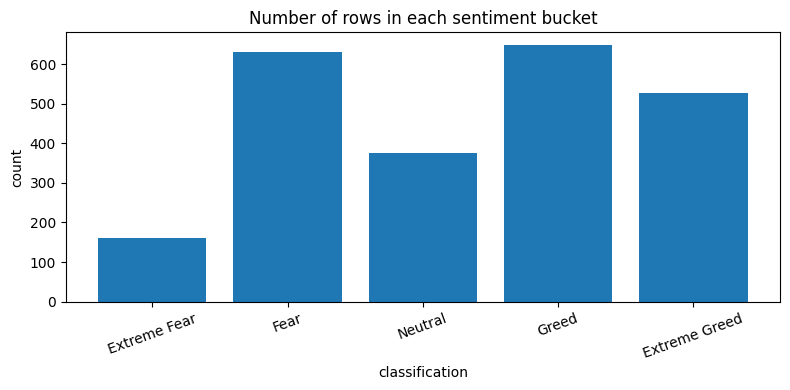

In [16]:
sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

sentiment_counts = (
    df["classification"]
    .value_counts()
    .reindex(sentiment_order)
    .dropna()
    .reset_index()
)
sentiment_counts.columns = ["classification", "count"]

display(sentiment_counts)

plt.figure(figsize=(8, 4))
plt.bar(sentiment_counts["classification"], sentiment_counts["count"])
plt.title("Number of rows in each sentiment bucket")
plt.xlabel("classification")
plt.ylabel("count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 1) Does performance change between Fear and Greed?

I am checking average daily PnL and win rate by sentiment class first, then a boxplot to see how spread out the PnL values are.

In [17]:
perf_table = (
    df.groupby("classification")[["daily_pnl", "win_rate"]]
    .agg(["mean", "median"])
    .round(4)
)

display(perf_table)

daily_pnl           win_rate        
                     mean    median     mean  median
classification                                      
Extreme Fear    4619.4391  218.3774   0.3297  0.3077
Extreme Greed   5161.9226  418.3199   0.3864  0.3571
Fear            5328.8182  107.8925   0.3640  0.3153
Greed           3318.1007  158.2149   0.3436  0.2892
Neutral         3438.6188  167.5517   0.3554  0.3211

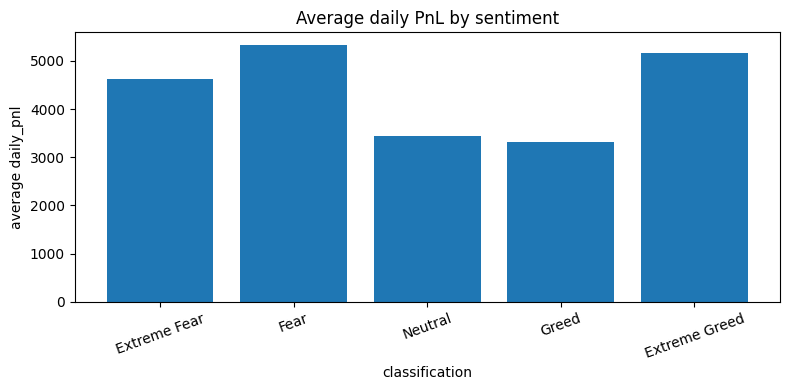

In [18]:
perf_pnl = df.groupby("classification")["daily_pnl"].mean().reindex(sentiment_order)

plt.figure(figsize=(8, 4))
plt.bar(perf_pnl.index, perf_pnl.values)
plt.title("Average daily PnL by sentiment")
plt.xlabel("classification")
plt.ylabel("average daily_pnl")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

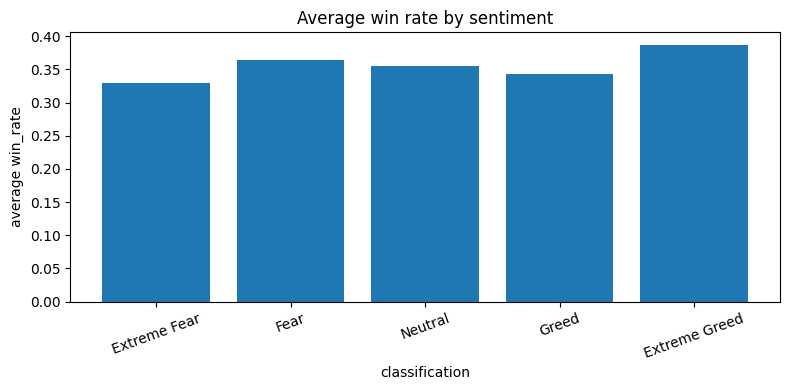

In [19]:
perf_win = df.groupby("classification")["win_rate"].mean().reindex(sentiment_order)

plt.figure(figsize=(8, 4))
plt.bar(perf_win.index, perf_win.values)
plt.title("Average win rate by sentiment")
plt.xlabel("classification")
plt.ylabel("average win_rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

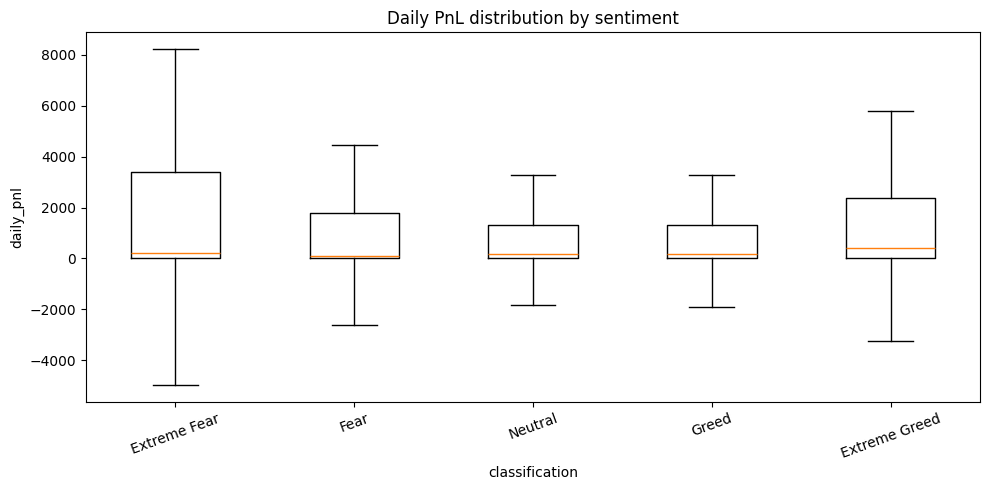

In [20]:
data = [df.loc[df["classification"] == c, "daily_pnl"] for c in sentiment_order if c in df["classification"].unique()]

plt.figure(figsize=(10, 5))
plt.boxplot(data, tick_labels=[c for c in sentiment_order if c in df["classification"].unique()], showfliers=False)
plt.title("Daily PnL distribution by sentiment")
plt.xlabel("classification")
plt.ylabel("daily_pnl")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 2) Do traders change behavior with sentiment?

Here I am comparing activity, position size, and directional bias across sentiment classes.

In [21]:
behavior_table = (
    df.groupby("classification")[["trades_per_day", "avg_trade_size", "long_short_ratio"]]
    .agg(["mean", "median"])
    .round(4)
)

display(behavior_table)

trades_per_day        avg_trade_size            long_short_ratio        
                         mean median           mean     median             mean  median
classification                                                                         
Extreme Fear         133.7500   50.5      6773.4641  2315.6299          69.2158  1.8937
Extreme Greed         76.0304   31.5      5371.6372  2003.4802          14.6510  1.0000
Fear                  98.1540   26.0      8975.9285  1752.6775          39.8006  1.0000
Greed                 77.6281   25.0      6427.8666  2052.5348          15.0418  1.0000
Neutral              100.2287   29.5      6963.6949  1704.4054          36.8771  1.0000

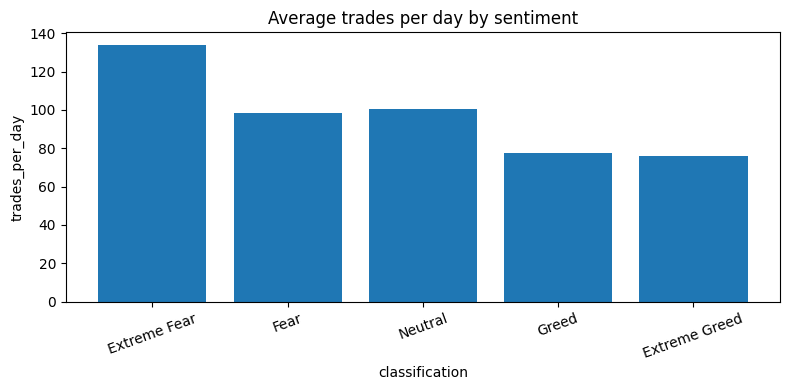

In [22]:
behavior_trades = df.groupby("classification")["trades_per_day"].mean().reindex(sentiment_order)

plt.figure(figsize=(8, 4))
plt.bar(behavior_trades.index, behavior_trades.values)
plt.title("Average trades per day by sentiment")
plt.xlabel("classification")
plt.ylabel("trades_per_day")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

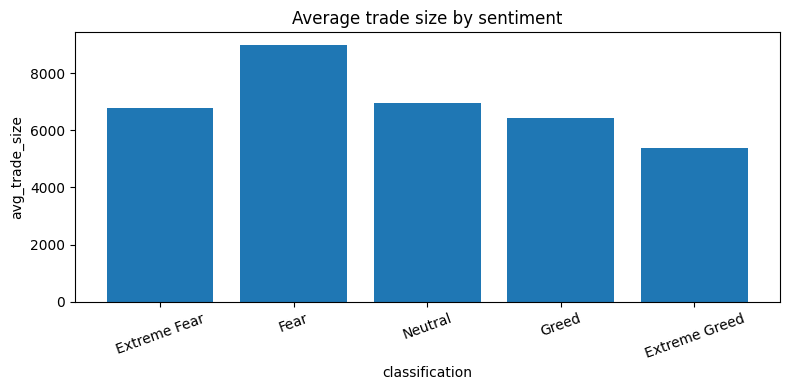

In [23]:
behavior_size = df.groupby("classification")["avg_trade_size"].mean().reindex(sentiment_order)

plt.figure(figsize=(8, 4))
plt.bar(behavior_size.index, behavior_size.values)
plt.title("Average trade size by sentiment")
plt.xlabel("classification")
plt.ylabel("avg_trade_size")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

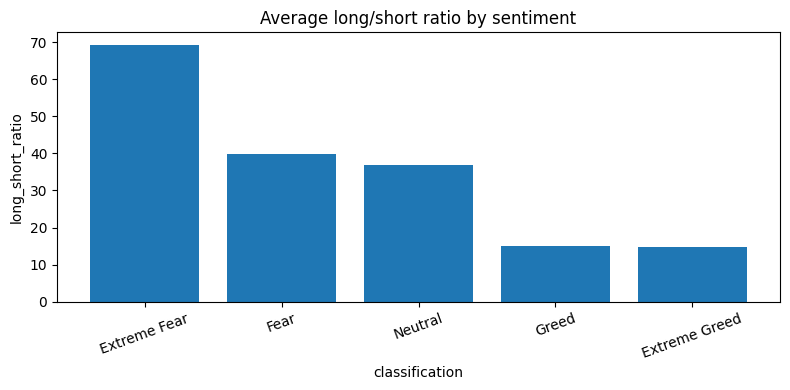

In [24]:
behavior_ratio = df.groupby("classification")["long_short_ratio"].mean().reindex(sentiment_order)

plt.figure(figsize=(8, 4))
plt.bar(behavior_ratio.index, behavior_ratio.values)
plt.title("Average long/short ratio by sentiment")
plt.xlabel("classification")
plt.ylabel("long_short_ratio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3) Trader segments

The assignment asks for a few trader groups. I used simple groups that are easy to explain from the cleaned data:

- frequent vs infrequent traders
- consistent vs inconsistent traders
- profitable vs less profitable traders



In [25]:
account_summary = (
    df.groupby("Account")
    .agg(
        total_pnl=("daily_pnl", "sum"),
        avg_daily_pnl=("daily_pnl", "mean"),
        pnl_std=("daily_pnl", "std"),
        avg_trades=("trades_per_day", "mean"),
        avg_size=("avg_trade_size", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_long_short=("long_short_ratio", "mean"),
        active_days=("date", "nunique"),
    )
    .reset_index()
)

account_summary["pnl_std"] = account_summary["pnl_std"].fillna(0)

display(account_summary.head())

,Account,total_pnl,avg_daily_pnl,pnl_std,avg_trades,avg_size,avg_win_rate,avg_long_short,active_days
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,66676.242499,150401.797346,159.083333,33569.102224,0.352333,0.121178,24
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,920.871548,3603.042291,140.000000,4359.830930,0.397134,6.590135,52
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-5869.682610,33420.410014,317.416667,11057.118419,0.379952,0.223841,12
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,817.684040,2993.284702,82.166667,484.844294,0.452509,8.348618,162
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,2444.318913,4867.743469,46.942029,2553.757037,0.498708,47.903382,69


In [26]:
# Frequent vs infrequent traders
account_summary["freq_group"] = pd.qcut(
    account_summary["avg_trades"],
    2,
    labels=["Infrequent", "Frequent"]
)

freq_accounts = account_summary[["Account", "freq_group"]]
freq_df = df.merge(freq_accounts, on="Account", how="left")

freq_table = (
    freq_df.groupby(["freq_group", "classification"])[["daily_pnl", "win_rate"]]
    .mean()
    .round(4)
)

display(freq_table)

daily_pnl  win_rate
freq_group classification                     
Infrequent Extreme Fear    3727.7703    0.2959
           Extreme Greed   5800.3618    0.3419
           Fear            2249.7751    0.3208
           Greed           1942.3749    0.2856
           Neutral         2891.8792    0.3021
Frequent   Extreme Fear    5406.2056    0.3595
           Extreme Greed   4340.2792    0.4437
           Fear            8672.9444    0.4110
           Greed           5494.0496    0.4352
           Neutral         4130.2774    0.4228

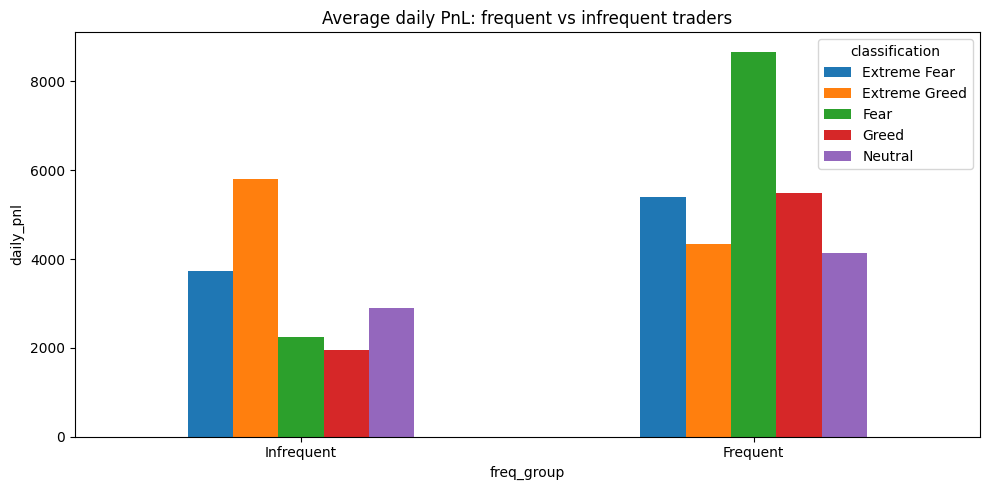

In [27]:
freq_plot = (
    freq_df.groupby(["freq_group", "classification"])["daily_pnl"]
    .mean()
    .unstack("classification")
)

freq_plot = freq_plot.reindex(["Infrequent", "Frequent"])

freq_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Average daily PnL: frequent vs infrequent traders")
plt.xlabel("freq_group")
plt.ylabel("daily_pnl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Consistent vs inconsistent traders
pnl_median = account_summary["pnl_std"].median()

account_summary["consistency_group"] = np.where(
    account_summary["pnl_std"] <= pnl_median,
    "Consistent",
    "Inconsistent"
)

consistency_accounts = account_summary[["Account", "consistency_group"]]
consistency_df = df.merge(consistency_accounts, on="Account", how="left")

consistency_table = (
    consistency_df.groupby(["consistency_group", "classification"])[["daily_pnl", "win_rate"]]
    .mean()
    .round(4)
)

display(consistency_table)

daily_pnl  win_rate
consistency_group classification                      
Consistent        Extreme Fear      171.4509    0.3022
                  Extreme Greed    2520.6492    0.4176
                  Fear              287.4741    0.3766
                  Greed            1199.7211    0.3729
                  Neutral           554.1099    0.3915
Inconsistent      Extreme Fear     8643.8093    0.3545
                  Extreme Greed   11971.7365    0.3059
                  Fear            10804.1853    0.3504
                  Greed            6757.2515    0.2959
                  Neutral          7418.5108    0.3057

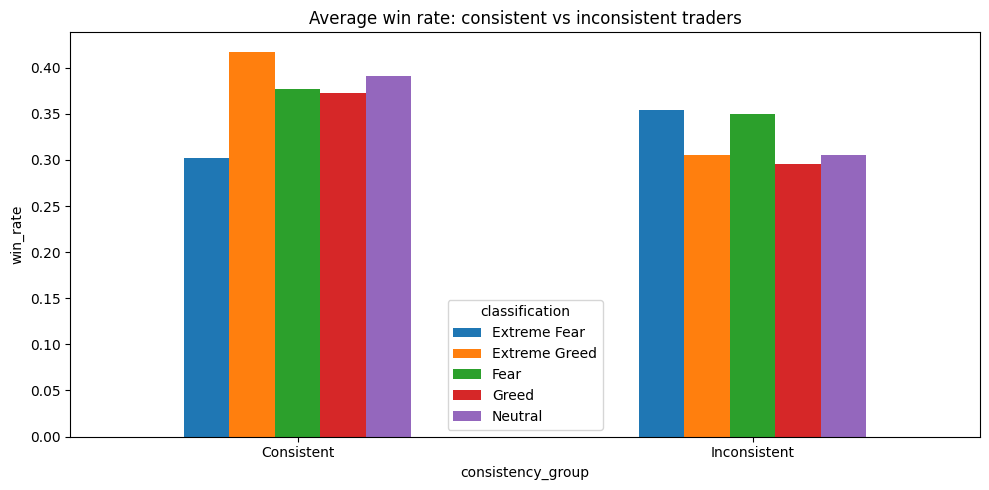

In [29]:
consistency_plot = (
    consistency_df.groupby(["consistency_group", "classification"])["win_rate"]
    .mean()
    .unstack("classification")
)

consistency_plot = consistency_plot.reindex(["Consistent", "Inconsistent"])

consistency_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Average win rate: consistent vs inconsistent traders")
plt.xlabel("consistency_group")
plt.ylabel("win_rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Profitable vs less profitable traders
account_summary["profit_group"] = pd.qcut(
    account_summary["total_pnl"],
    2,
    labels=["Lower PnL", "Higher PnL"]
)

profit_accounts = account_summary[["Account", "profit_group"]]
profit_df = df.merge(profit_accounts, on="Account", how="left")

profit_table = (
    profit_df.groupby(["profit_group", "classification"])[["daily_pnl", "win_rate"]]
    .mean()
    .round(4)
)

display(profit_table)

daily_pnl  win_rate
profit_group classification                      
Lower PnL    Extreme Fear    -2121.1011    0.2738
             Extreme Greed    2176.5270    0.3464
             Fear             1306.4206    0.3445
             Greed            -865.2041    0.3491
             Neutral           504.3310    0.3093
Higher PnL   Extreme Fear    10134.4264    0.3754
             Extreme Greed    6850.0928    0.4090
             Fear             8082.1170    0.3774
             Greed            5543.2629    0.3406
             Neutral          5301.2537    0.3847

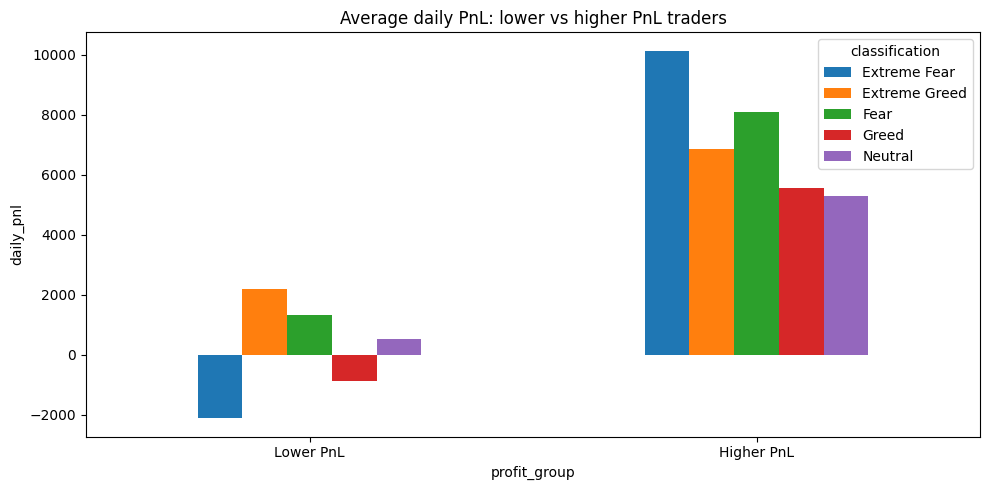

In [31]:
profit_plot = (
    profit_df.groupby(["profit_group", "classification"])["daily_pnl"]
    .mean()
    .unstack("classification")
)

profit_plot = profit_plot.reindex(["Lower PnL", "Higher PnL"])

profit_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Average daily PnL: lower vs higher PnL traders")
plt.xlabel("profit_group")
plt.ylabel("daily_pnl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4) A small correlation check

This is not the main answer, but it is useful as a quick sanity check before writing the final observations.

In [32]:
corr_cols = ["daily_pnl", "trades_per_day", "avg_trade_size", "win_rate", "long_short_ratio", "value"]
corr = df[corr_cols].corr().round(3)

display(corr)

,daily_pnl,trades_per_day,avg_trade_size,win_rate,long_short_ratio,value
daily_pnl,1.000,0.176,0.028,0.210,0.145,0.000
trades_per_day,0.176,1.000,-0.026,0.063,0.694,-0.065
avg_trade_size,0.028,-0.026,1.000,0.032,0.004,-0.057
win_rate,0.210,0.063,0.032,1.000,0.038,0.027
long_short_ratio,0.145,0.694,0.004,0.038,1.000,-0.099
value,0.000,-0.065,-0.057,0.027,-0.099,1.000


## What to write in the final report

Keep it simple:
- compare performance in Fear vs Greed
- compare trading behavior in Fear vs Greed
- explain which trader segment behaves better or worse
- end with 2 clear rules of thumb

I would not overcomplicate this notebook. The cleaner the story, the better.
